In [8]:
import plotly.express as px


DATASET PREVIEW

   10_Digit_BBL  Street_Number     Street_Name  DOF_Gross_Square_Footage  \
0    1007610020            325  WEST 37 STREET                     48843   
1    1007610022            313  WEST 37 STREET                     82354   
2    1007610028            307  WEST 37 STREET                    102824   
3    1007610033            545        8 AVENUE                    166874   
4    1007610037            555        8 AVENUE                    162260   

  Energy_Efficiency_Grade  Energy_Star_1-100_Score  
0                       A                      100  
1                       C                       62  
2                       B                       79  
3                       A                       86  
4                       A                      100  

DATASET COLUMNS

Index(['10_Digit_BBL', 'Street_Number', 'Street_Name',
       'DOF_Gross_Square_Footage', 'Energy_Efficiency_Grade',
       'Energy_Star_1-100_Score'],
      dtype='object')

MISSING VALUES

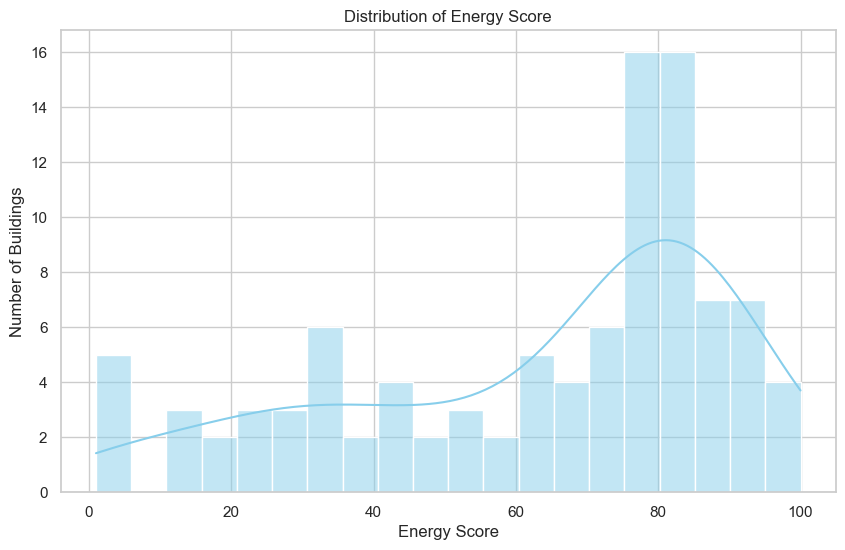

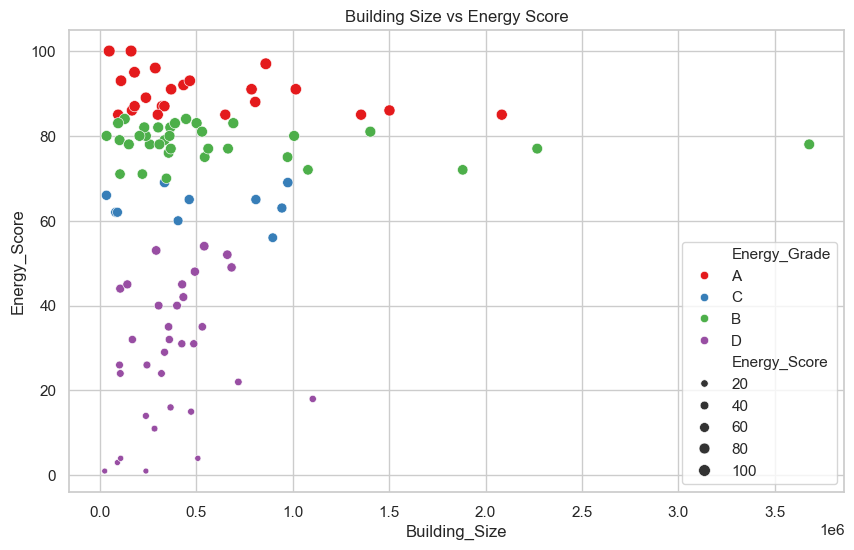

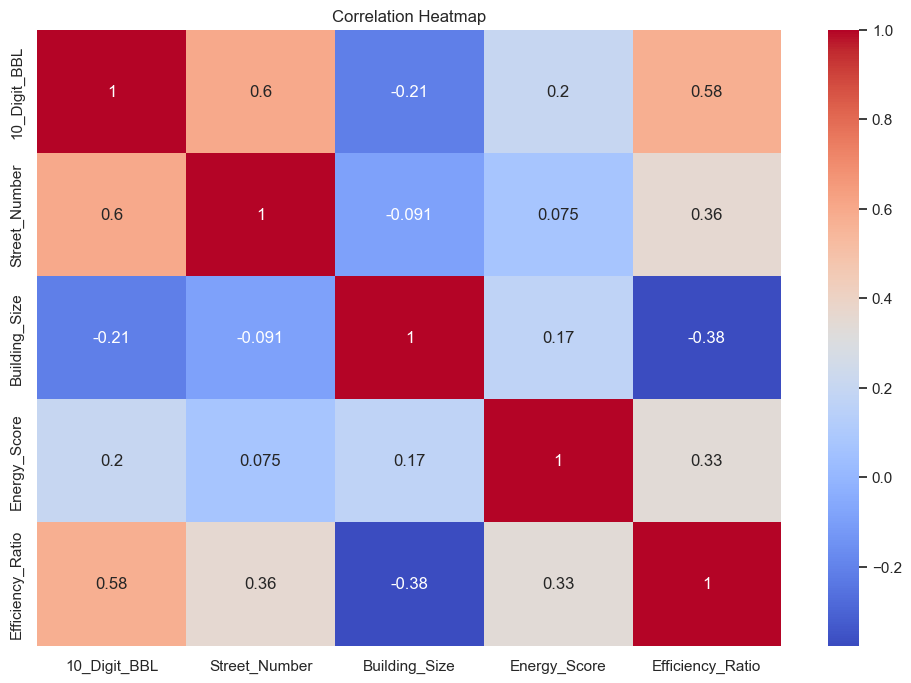


TOP 10 MOST EFFICIENT BUILDINGS

       Street_Name  Energy_Score Energy_Grade
0   WEST 37 STREET           100            A
4         8 AVENUE           100            A
59        BROADWAY            97            A
45    RECTOR PLACE            96            A
6   WEST 38 STREET            95            A
64    BROAD STREET            93            A
9   WEST 38 STREET            93            A
22        BROADWAY            92            A
66    BROAD STREET            91            A
10    BROAD STREET            91            A

TOP 10 MOST WASTEFUL BUILDINGS

             Street_Name  Energy_Score Energy_Grade
35      NORTH END AVENUE             1            D
86  SOUTH WILLIAM STREET             1            D
70          BROAD STREET             3            D
47         BATTERY PLACE             4            D
82         BEAVER STREET             4            D
34      NORTH END AVENUE            11            D
79        HANOVER SQUARE            14            D
92         

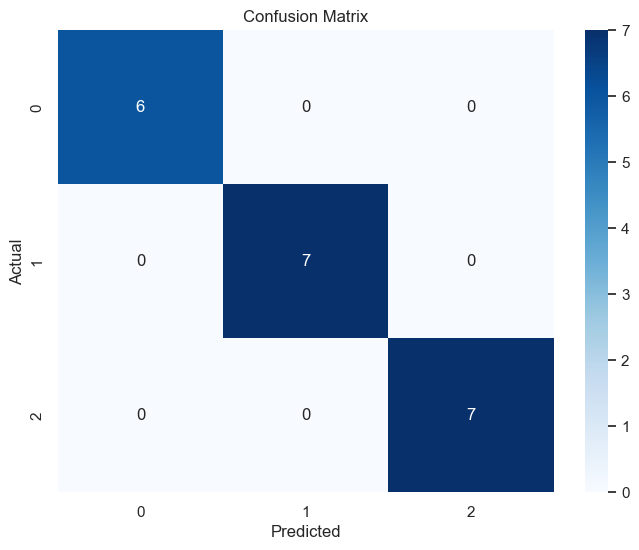


FEATURE IMPORTANCE

            Feature  Importance
1      Energy_Score    0.727000
2  Efficiency_Ratio    0.155451
0     Building_Size    0.112741
3  Category_Encoded    0.004808


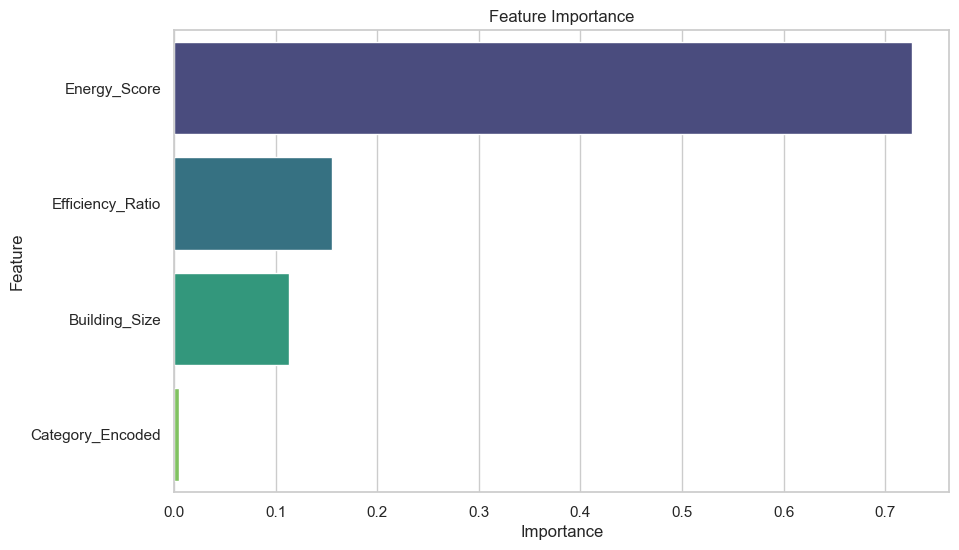

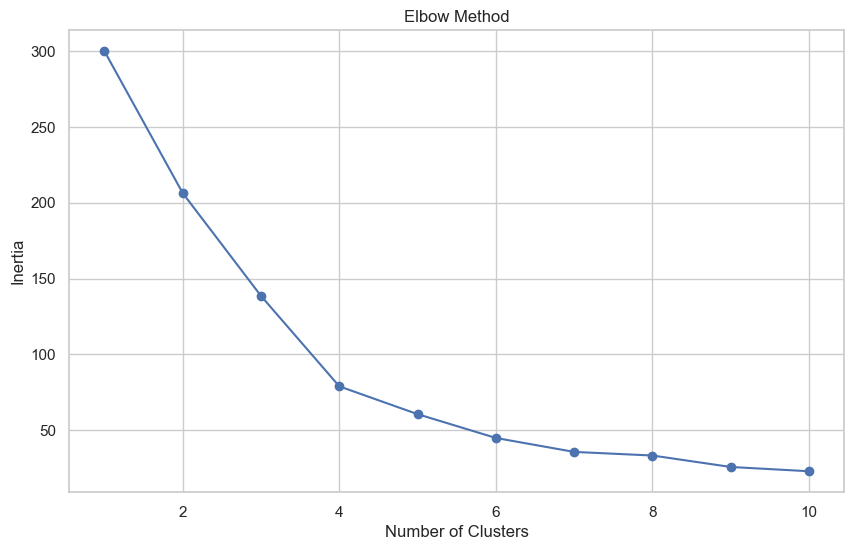


CLUSTER RESULT

      Street_Name  Cluster
0  WEST 37 STREET        2
1  WEST 37 STREET        1
2  WEST 37 STREET        1
3        8 AVENUE        1
4        8 AVENUE        1


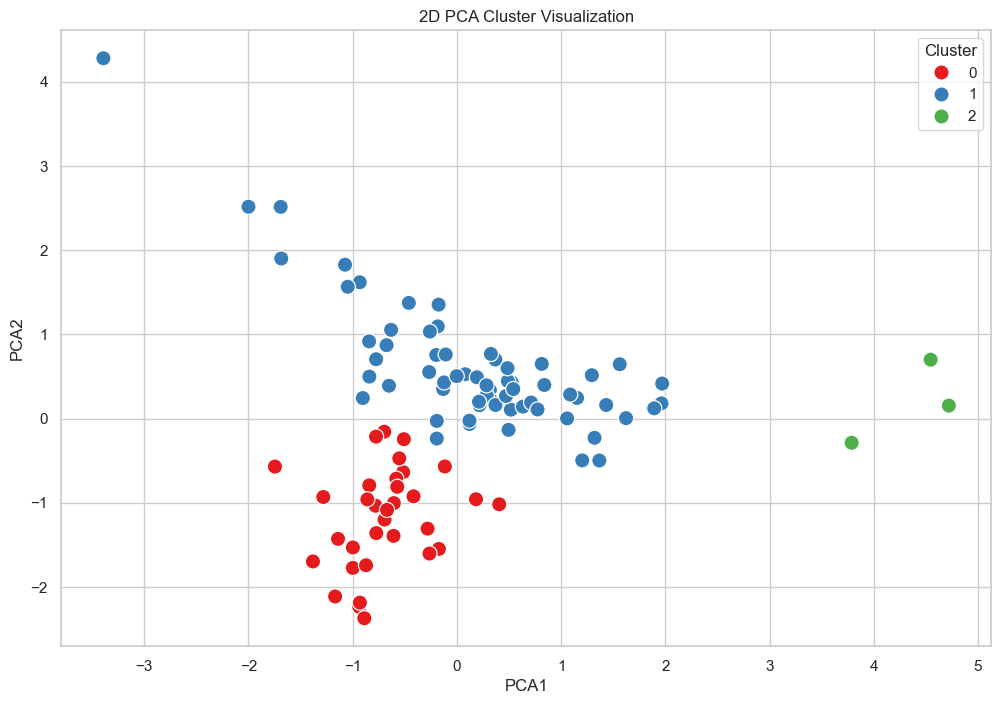


3D VISUALIZATION SAVED!

DATASET SAVED SUCCESSFULLY!

PROJECT FINISHED SUCCESSFULLY!


In [9]:
# =========================================================
# AI SMART BUILDING ENERGY INTELLIGENCE SYSTEM
# FULL FINAL VERSION
# =========================================================

# =========================================================
# INSTALL LIBRARY
# =========================================================

# pip install pandas numpy matplotlib seaborn scikit-learn plotly

# =========================================================
# IMPORT LIBRARY
# =========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings('ignore')

# =========================================================
# LOAD DATASET
# =========================================================

df = pd.read_csv("energy_disclosure_2021_rows.csv")

print("\nDATASET PREVIEW\n")

print(df.head())

print("\nDATASET COLUMNS\n")

print(df.columns)

# =========================================================
# DATA CLEANING
# =========================================================

print("\nMISSING VALUES\n")

print(df.isnull().sum())

# REMOVE MISSING VALUES
df.dropna(inplace=True)

# REMOVE DUPLICATES
df.drop_duplicates(inplace=True)

print("\nDATASET SHAPE AFTER CLEANING\n")

print(df.shape)

# =========================================================
# RENAME COLUMNS
# =========================================================

df.rename(columns={

    'DOF_Gross_Square_Footage': 'Building_Size',
    'Energy_Star_1-100_Score': 'Energy_Score',
    'Energy_Efficiency_Grade': 'Energy_Grade'

}, inplace=True)

# =========================================================
# FEATURE ENGINEERING
# =========================================================

df['Efficiency_Ratio'] = (
    df['Energy_Score'] / df['Building_Size']
)

# =========================================================
# BUILDING CATEGORY
# =========================================================

def building_category(size):

    if size < 50000:
        return 'Small'

    elif size < 150000:
        return 'Medium'

    elif size < 300000:
        return 'Large'

    else:
        return 'Mega'

df['Building_Category'] = (
    df['Building_Size'].apply(building_category)
)

# =========================================================
# ENERGY RISK LEVEL
# =========================================================

def energy_risk(score):

    if score >= 85:
        return 'Low Risk'

    elif score >= 60:
        return 'Medium Risk'

    else:
        return 'High Risk'

df['Risk_Level'] = (
    df['Energy_Score'].apply(energy_risk)
)

print("\nFEATURE ENGINEERING RESULT\n")

print(df.head())

# =========================================================
# EXPLORATORY DATA ANALYSIS
# =========================================================

sns.set(style="whitegrid")

# =========================================================
# ENERGY SCORE DISTRIBUTION
# =========================================================

plt.figure(figsize=(10,6))

sns.histplot(

    df['Energy_Score'],
    bins=20,
    kde=True,
    color='skyblue'

)

plt.title("Distribution of Energy Score")

plt.xlabel("Energy Score")
plt.ylabel("Number of Buildings")

plt.show()

# =========================================================
# BUILDING SIZE VS ENERGY SCORE
# =========================================================

plt.figure(figsize=(10,6))

sns.scatterplot(

    x='Building_Size',
    y='Energy_Score',

    hue='Energy_Grade',

    size='Energy_Score',

    data=df,

    palette='Set1'

)

plt.title("Building Size vs Energy Score")

plt.show()

# =========================================================
# CORRELATION HEATMAP
# =========================================================

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))

sns.heatmap(

    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'

)

plt.title("Correlation Heatmap")

plt.show()

# =========================================================
# TOP 10 MOST EFFICIENT BUILDINGS
# =========================================================

top_buildings = (

    df.sort_values(
        by='Energy_Score',
        ascending=False
    ).head(10)

)

print("\nTOP 10 MOST EFFICIENT BUILDINGS\n")

print(

    top_buildings[
        [
            'Street_Name',
            'Energy_Score',
            'Energy_Grade'
        ]
    ]

)

# =========================================================
# TOP 10 MOST WASTEFUL BUILDINGS
# =========================================================

worst_buildings = (

    df.sort_values(
        by='Energy_Score'
    ).head(10)

)

print("\nTOP 10 MOST WASTEFUL BUILDINGS\n")

print(

    worst_buildings[
        [
            'Street_Name',
            'Energy_Score',
            'Energy_Grade'
        ]
    ]

)

# =========================================================
# LABEL ENCODING
# =========================================================

encoder = LabelEncoder()

df['Grade_Encoded'] = (
    encoder.fit_transform(df['Energy_Grade'])
)

df['Category_Encoded'] = (
    encoder.fit_transform(df['Building_Category'])
)

# =========================================================
# MACHINE LEARNING
# =========================================================

X = df[
    [
        'Building_Size',
        'Energy_Score',
        'Efficiency_Ratio',
        'Category_Encoded'
    ]
]

y = df['Grade_Encoded']

# =========================================================
# TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,
    random_state=42

)

# =========================================================
# STANDARDIZATION
# =========================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# =========================================================
# DECISION TREE
# =========================================================

print("\n==============================")
print("DECISION TREE")
print("==============================")

dt_model = DecisionTreeClassifier(
    max_depth=5
)

dt_model.fit(X_train_scaled, y_train)

dt_pred = dt_model.predict(X_test_scaled)

print(
    "Accuracy:",
    accuracy_score(y_test, dt_pred)
)

print(
    classification_report(y_test, dt_pred)
)

# =========================================================
# RANDOM FOREST
# =========================================================

print("\n==============================")
print("RANDOM FOREST")
print("==============================")

rf_model = RandomForestClassifier(

    n_estimators=200,
    max_depth=10,
    random_state=42

)

rf_model.fit(X_train_scaled, y_train)

rf_pred = rf_model.predict(X_test_scaled)

print(
    "Accuracy:",
    accuracy_score(y_test, rf_pred)
)

print(
    classification_report(y_test, rf_pred)
)

# =========================================================
# CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(8,6))

sns.heatmap(

    cm,
    annot=True,
    fmt='d',
    cmap='Blues'

)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# =========================================================
# FEATURE IMPORTANCE
# =========================================================

importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({

    'Feature': X.columns,
    'Importance': importance

})

feature_importance = (

    feature_importance.sort_values(
        by='Importance',
        ascending=False
    )

)

print("\nFEATURE IMPORTANCE\n")

print(feature_importance)

plt.figure(figsize=(10,6))

sns.barplot(

    x='Importance',
    y='Feature',

    data=feature_importance,

    palette='viridis'

)

plt.title("Feature Importance")

plt.show()

# =========================================================
# CLUSTERING
# =========================================================

cluster_features = df[
    [
        'Building_Size',
        'Energy_Score',
        'Efficiency_Ratio'
    ]
]

cluster_scaler = StandardScaler()

cluster_scaled = (
    cluster_scaler.fit_transform(cluster_features)
)

# =========================================================
# ELBOW METHOD
# =========================================================

inertia = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(cluster_scaled)

    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10,6))

plt.plot(

    range(1,11),
    inertia,
    marker='o'

)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()

# =========================================================
# FINAL KMEANS
# =========================================================

kmeans = KMeans(

    n_clusters=3,
    random_state=42

)

df['Cluster'] = (
    kmeans.fit_predict(cluster_scaled)
)

print("\nCLUSTER RESULT\n")

print(

    df[
        ['Street_Name', 'Cluster']
    ].head()

)

# =========================================================
# PCA 2D VISUALIZATION
# =========================================================

pca = PCA(n_components=2)

pca_result = pca.fit_transform(cluster_scaled)

df['PCA1'] = pca_result[:,0]
df['PCA2'] = pca_result[:,1]

plt.figure(figsize=(12,8))

sns.scatterplot(

    x='PCA1',
    y='PCA2',

    hue='Cluster',

    data=df,

    palette='Set1',
    s=120

)

plt.title("2D PCA Cluster Visualization")

plt.show()

# =========================================================
# PCA 3D VISUALIZATION
# =========================================================

pca_3d = PCA(n_components=3)

pca_result_3d = pca_3d.fit_transform(cluster_scaled)

df['PCA1_3D'] = pca_result_3d[:,0]
df['PCA2_3D'] = pca_result_3d[:,1]
df['PCA3_3D'] = pca_result_3d[:,2]

fig = px.scatter_3d(

    df,

    x='PCA1_3D',
    y='PCA2_3D',
    z='PCA3_3D',

    color='Cluster',

    hover_data=[
        'Street_Name',
        'Energy_Score'
    ],

    title='3D PCA Cluster Visualization'
)

# SAVE HTML FILE
fig.write_html("3D_Visualization.html")

print("\n3D VISUALIZATION SAVED!")

# =========================================================
# SAVE CLEAN DATASET
# =========================================================

df.to_csv(
    'clean_energy_building_dataset.csv',
    index=False
)

print("\nDATASET SAVED SUCCESSFULLY!")

# =========================================================
# FINAL RESULT
# =========================================================

print("\nPROJECT FINISHED SUCCESSFULLY!")